<!-- ### Exploratory Data Analysis for the Ecoplanet - Acre Bamboo Merged Parameters
##### Goal: To understand the dataset, the relationships that exist in the dataset, and whether the data we have is good for modelling
##### Author: Elkana Kipruto -->

In [1]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os

<!-- ##### Dataset Path -->

In [28]:
inter_dir = '../../02_INTERMEDIATE'
merged_filepath = f'{inter_dir}/final_bamboo_parameters_v08.gpkg'
if os.path.exists(merged_filepath):
    gdf = gpd.read_file(merged_filepath)
else:
    print('Invalid source path')

In [29]:
gdf.to_csv(f'{inter_dir}/final_bamboo_params_v08.csv', index=False)

<!-- #### -------------------------------------------------
#### Step 1: Understanding the dataset
#### ------------------------------------------------- -->

In [22]:
gdf.head()

,psp,year,date_of_collection,clump_id,total_culms,total_agb,max_culm_diameter_cm,avg_culm_diameter_cm,min_culm_diameter_cm,median_culm_diameter_cm,...,bh_hollow_equivalent_diameter_m,bh_hollow_fraction,bh_solid_fraction,bh_outside_area_m2,bh_slice_to_original_area_ratio,bh_n_hollows,bh_slice_valid,bh_n_positive_cells,bh_n_valid_cells,geometry
0,1a-APM-01,2025,4/24/2025,CLUMP #1,11,34.65,2.78,1.86,0.36,1.85,...,0.0276395316348677,1.9868160785644137e-05,0.9999801318392144,2.6706702323095897,0.9187498841742094,1,1,4317,82159,POINT (798563.99 9777833.328)
1,1a-APM-01,2026,4/2/2026,CLUMP #1,31,144.28,3.59,2.35,0.66,2.45,...,0.0355036219949278,2.6367564716611008e-05,0.9999736324352834,4.449121038090269,0.894056568338251,2,1,2532,104989,POINT (798561.124 9777837.75)
2,1a-APM-01,2025,4/24/2025,CLUMP #2,14,16.47,2.16,1.06,0.39,0.93,...,0.0,0.0,1.0,0.4074810159259616,0.9220327603615496,0,1,829,13065,POINT (798566.87 9777828.479)
3,1a-APM-01,2026,4/2/2026,CLUMP #2,58,172.09,3.03,1.81,0.23,1.81,...,0.0276395316348677,1.9868160785644137e-05,0.9999801318392144,2.6706702323095897,0.9187498841742094,1,1,4317,82159,POINT (798563.966 9777833.328)
4,1a-APM-01,2025,4/24/2025,CLUMP #3,0,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,1.0,1.0986966579428117,0.9065127931896833,0,1,2059,29404,POINT (798567.766 9777823.46)


In [23]:
gdf.columns

Index(['psp', 'year', 'date_of_collection', 'clump_id', 'total_culms',
       'total_agb', 'max_culm_diameter_cm', 'avg_culm_diameter_cm',
       'min_culm_diameter_cm', 'median_culm_diameter_cm', 'max_culm_agb',
       'avg_culm_agb', 'min_culm_agb', 'median_culm_agb', 'hmin', 'hmax',
       'hmean', 'hstd', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'val_height', 'val_canopy_diameter',
       'bh_outer_area_m2', 'bh_outer_perimeter_m',
       'bh_outer_equivalent_diameter_m', 'bh_hollow_area_m2',
       'bh_hollow_perimeter_m', 'bh_hollow_equivalent_diameter_m',
       'bh_hollow_fraction', 'bh_solid_fraction', 'bh_outside_area_m2',
       'bh_slice_to_original_area_ratio', 'bh_n_hollows', 'bh_slice_valid',
       'bh_n_positive_cells', 'bh_n_valid_cells', 'geometry'],
      dtype='str')

In [24]:
# # 2. Define your columns explicitly based on your schema
# int_cols = ["year", "total_culms", "total_points"]

# # All your biometric, biomass (AGB), and canopy metrics
# float_cols = [
#     "total_agb",
#     "max_culm_diameter_cm",
#     "avg_culm_diameter_cm",
#     "min_culm_diameter_cm",
#     "median_culm_diameter_cm",
#     "max_culm_agb",
#     "avg_culm_agb",
#     "min_culm_agb",
#     "median_culm_agb",
#     "hmin",
#     "hmax",
#     "hmean",
#     "hstd",
#     "hmedian",
#     "canopy_volume_m3",
#     "gap_fraction",
#     "canopy_area",
#     "val_height",
#     "val_canopy_diameter",
#     'bh_outer_area_m2', 'bh_outer_perimeter_m',
#        'bh_outer_equivalent_diameter_m', 'bh_hollow_area_m2',
#        'bh_hollow_perimeter_m', 'bh_hollow_equivalent_diameter_m',
#        'bh_hollow_fraction', 'bh_solid_fraction', 'bh_outside_area_m2',
#        'bh_slice_to_original_area_ratio', 'bh_n_hollows', 'bh_slice_valid',
#        'bh_n_positive_cells', 'bh_n_valid_cells'
# ]

# # 3. Clean and convert Integer columns
# for col in int_cols:
#     if col in gdf.columns:
#         # pd.to_numeric turns invalid strings/spaces into NaN, fillna(0) prevents crashing
#         gdf[col] = pd.to_numeric(gdf[col], errors="coerce").fillna(0).astype("int64")

# # 4. Clean, convert, and round Float columns to strictly 2 decimal places
# for col in float_cols:
#     if col in gdf.columns:
#         # Convert text to actual decimals
#         gdf[col] = pd.to_numeric(gdf[col], errors="coerce")
#         # Round strictly to 2 decimal places
#         gdf[col] = gdf[col].round(2)

# # 5. Save the properly typed GeoPackage
# output_path = "../../02_INTERMEDIATE/final_bamboo_parameters_v08.gpkg"
# gdf.to_file(output_path, driver="GPKG")

# print("GeoPackage successfully cleaned and types corrected!")

In [25]:
gdf.shape

(225, 40)

In [26]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 40 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   psp                              225 non-null    str     
 1   year                             225 non-null    int64   
 2   date_of_collection               225 non-null    str     
 3   clump_id                         225 non-null    str     
 4   total_culms                      225 non-null    int64   
 5   total_agb                        225 non-null    float64 
 6   max_culm_diameter_cm             225 non-null    float64 
 7   avg_culm_diameter_cm             225 non-null    float64 
 8   min_culm_diameter_cm             225 non-null    float64 
 9   median_culm_diameter_cm          225 non-null    float64 
 10  max_culm_agb                     225 non-null    float64 
 11  avg_culm_agb                     225 non-null    float64 
 12  

In [27]:
gdf.describe()

,year,total_culms,total_agb,max_culm_diameter_cm,avg_culm_diameter_cm,min_culm_diameter_cm,median_culm_diameter_cm,max_culm_agb,avg_culm_agb,min_culm_agb,...,hmax,hmean,hstd,hmedian,total_points,canopy_volume_m3,gap_fraction,canopy_area,val_height,val_canopy_diameter
count,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,...,173.000000,173.000000,173.000000,173.000000,225.000000,173.000000,173.000000,173.000000,54.000000,42.000000
mean,2025.533333,22.320000,81.533822,2.201822,1.316533,0.482533,1.303600,5.323378,2.272800,0.360844,...,5.079075,4.371387,0.744855,4.457688,130268.475556,139.484162,0.160809,23.299538,5.709259,5.700000
std,0.500000,21.198147,100.349163,1.571936,0.909020,0.384082,0.927828,5.486913,2.025274,0.438828,...,1.543376,1.124484,0.348630,1.181913,131807.308726,104.704620,0.084677,14.743072,1.622980,1.243716
min,2025.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.100000,1.490000,0.070000,1.680000,0.000000,0.570000,0.010000,0.350000,2.000000,3.000000
25%,2025.000000,3.000000,1.310000,0.720000,0.470000,0.240000,0.410000,0.510000,0.260000,0.070000,...,3.800000,3.480000,0.460000,3.550000,9274.000000,43.660000,0.090000,10.970000,4.900000,4.600000
50%,2026.000000,16.000000,35.720000,2.530000,1.540000,0.410000,1.480000,4.960000,2.160000,0.190000,...,5.140000,4.500000,0.750000,4.570000,96227.000000,122.080000,0.170000,22.110000,5.850000,5.950000
75%,2026.000000,38.000000,141.690000,3.380000,2.020000,0.700000,2.020000,8.390000,3.530000,0.500000,...,6.080000,5.090000,1.000000,5.370000,229822.000000,223.510000,0.230000,34.000000,6.200000,6.700000
max,2026.000000,82.000000,382.050000,9.040000,3.190000,1.650000,3.330000,49.410000,8.660000,2.200000,...,8.650000,6.800000,1.670000,7.390000,567417.000000,431.760000,0.310000,59.840000,8.400000,7.400000


<Axes: >

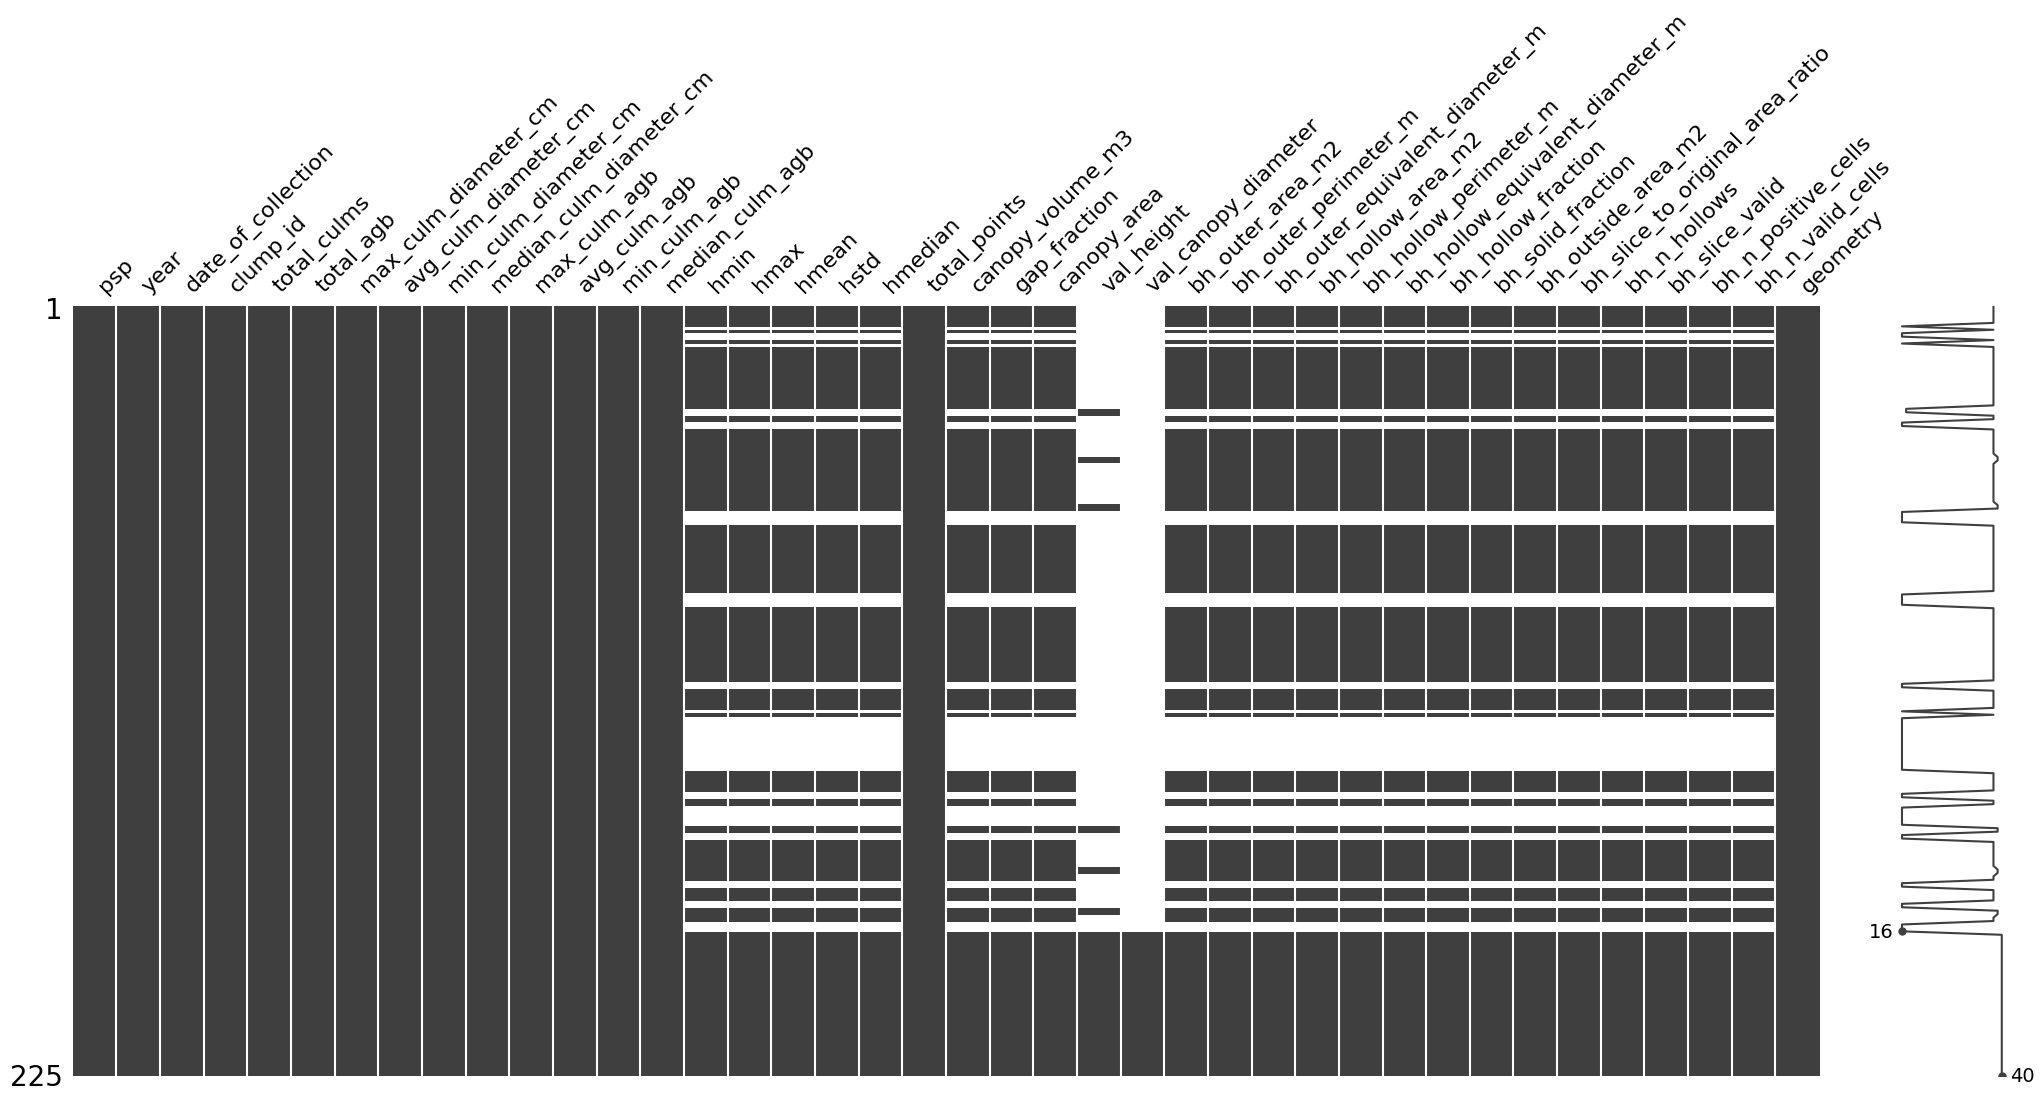

In [9]:
msno.matrix(gdf)

In [10]:
gdf.duplicated().sum()

np.int64(0)

###### Check for impossible values

In [11]:
numeric_cols = gdf.select_dtypes(include='number').columns

In [12]:
for col in numeric_cols:
    print(col, gdf[gdf[col] < 0].shape)

year (0, 40)
total_culms (0, 40)
total_agb (0, 40)
max_culm_diameter_cm (0, 40)
avg_culm_diameter_cm (0, 40)
min_culm_diameter_cm (0, 40)
median_culm_diameter_cm (0, 40)
max_culm_agb (0, 40)
avg_culm_agb (0, 40)
min_culm_agb (0, 40)
median_culm_agb (0, 40)
hmin (0, 40)
hmax (0, 40)
hmean (0, 40)
hstd (0, 40)
hmedian (0, 40)
total_points (0, 40)
canopy_volume_m3 (0, 40)
gap_fraction (0, 40)
canopy_area (0, 40)
val_height (0, 40)
val_canopy_diameter (0, 40)
bh_outer_area_m2 (0, 40)
bh_outer_perimeter_m (0, 40)
bh_outer_equivalent_diameter_m (0, 40)
bh_hollow_area_m2 (0, 40)
bh_hollow_perimeter_m (0, 40)
bh_hollow_equivalent_diameter_m (0, 40)
bh_hollow_fraction (0, 40)
bh_solid_fraction (0, 40)
bh_outside_area_m2 (0, 40)
bh_slice_to_original_area_ratio (0, 40)
bh_n_hollows (0, 40)
bh_slice_valid (0, 40)
bh_n_positive_cells (0, 40)
bh_n_valid_cells (0, 40)


###### No impossible figures

#### Is 2025 data meaningful to the analysis?

In [13]:
gdf.groupby("year")["total_agb"].describe()

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2025,105.0,37.817238,53.213011,0.0,0.0000,10.490,54.6000,218.39
2026,120.0,119.785833,115.406669,0.0,7.3475,100.345,200.0825,382.05


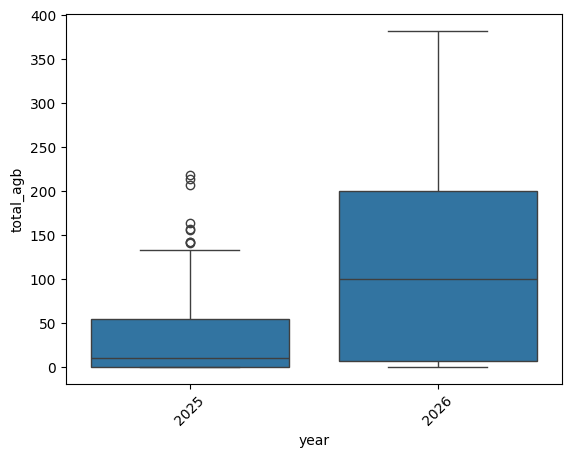

In [14]:
sns.boxplot(
    data=gdf,
    x="year",
    y="total_agb"
)

plt.xticks(rotation=45)
plt.show()

#### Findings:
* **2025 data differs very much with 2026:** The changes in the clumps btn 2025 and 2026 are massive and given they share the same drone metrics, this would confuse the model and so should drop 2025.

#### Does 2026 data for March vs June Differ much in GB-05?

##### What does the biomass look like

In [15]:
gdf = gdf[gdf['year'] == 2026]
gdf = gdf[gdf['total_agb'] != 0]

In [16]:
gdf.columns

Index(['psp', 'year', 'date_of_collection', 'clump_id', 'total_culms',
       'total_agb', 'max_culm_diameter_cm', 'avg_culm_diameter_cm',
       'min_culm_diameter_cm', 'median_culm_diameter_cm', 'max_culm_agb',
       'avg_culm_agb', 'min_culm_agb', 'median_culm_agb', 'hmin', 'hmax',
       'hmean', 'hstd', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'val_height', 'val_canopy_diameter',
       'bh_outer_area_m2', 'bh_outer_perimeter_m',
       'bh_outer_equivalent_diameter_m', 'bh_hollow_area_m2',
       'bh_hollow_perimeter_m', 'bh_hollow_equivalent_diameter_m',
       'bh_hollow_fraction', 'bh_solid_fraction', 'bh_outside_area_m2',
       'bh_slice_to_original_area_ratio', 'bh_n_hollows', 'bh_slice_valid',
       'bh_n_positive_cells', 'bh_n_valid_cells', 'geometry'],
      dtype='str')

In [17]:
gdf['total_agb'].describe()

count    104.000000
mean     138.214423
std      113.206879
min        0.100000
25%       36.157500
50%      133.165000
75%      212.332500
max      382.050000
Name: total_agb, dtype: float64

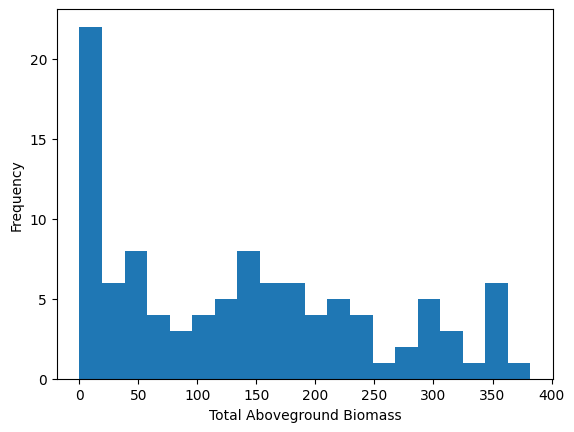

In [18]:
plt.hist(gdf['total_agb'], bins=20)
plt.xlabel('Total Aboveground Biomass')
plt.ylabel('Frequency')
plt.show()

In [19]:
gdf['total_agb'].skew()

np.float64(0.4806249809545793)

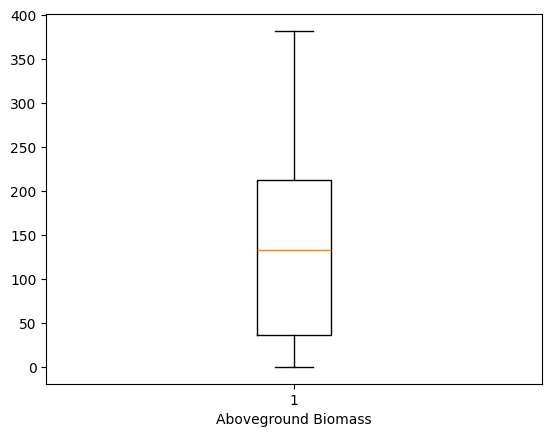

In [20]:
plt.boxplot(gdf['total_agb'])
plt.xlabel('Aboveground Biomass')
plt.show()

##### What do the drone metrics look like

In [21]:
gdf.columns

Index(['psp', 'year', 'date_of_collection', 'clump_id', 'total_culms',
       'total_agb', 'max_culm_diameter_cm', 'avg_culm_diameter_cm',
       'min_culm_diameter_cm', 'median_culm_diameter_cm', 'max_culm_agb',
       'avg_culm_agb', 'min_culm_agb', 'median_culm_agb', 'hmin', 'hmax',
       'hmean', 'hstd', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'val_height', 'val_canopy_diameter',
       'bh_outer_area_m2', 'bh_outer_perimeter_m',
       'bh_outer_equivalent_diameter_m', 'bh_hollow_area_m2',
       'bh_hollow_perimeter_m', 'bh_hollow_equivalent_diameter_m',
       'bh_hollow_fraction', 'bh_solid_fraction', 'bh_outside_area_m2',
       'bh_slice_to_original_area_ratio', 'bh_n_hollows', 'bh_slice_valid',
       'bh_n_positive_cells', 'bh_n_valid_cells', 'geometry'],
      dtype='str')

In [51]:
gdf['adjusted_volume'] = gdf['canopy_volume_m3'] * gdf['gap_fraction']

In [22]:
predictors = [
       'hmean', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'bh_outer_area_m2', 'bh_outer_perimeter_m',
       'bh_outer_equivalent_diameter_m', 'bh_hollow_area_m2',
       'bh_hollow_perimeter_m', 'bh_hollow_equivalent_diameter_m',
       'bh_hollow_fraction', 'bh_solid_fraction', 'bh_outside_area_m2',
       'bh_slice_to_original_area_ratio', 'bh_n_hollows', 'bh_slice_valid',
       'bh_n_positive_cells', 'bh_n_valid_cells'
]

In [23]:
predictors_gdf = gdf.dropna(subset=predictors).copy()

In [24]:
print(f'{len(gdf)} removed zeros {len(predictors_gdf)}')

104 removed zeros 92


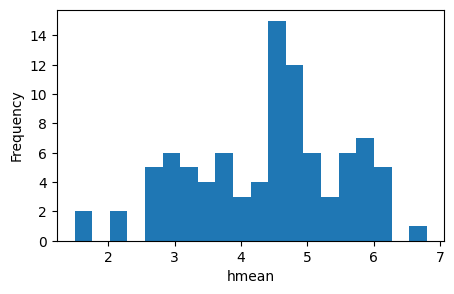

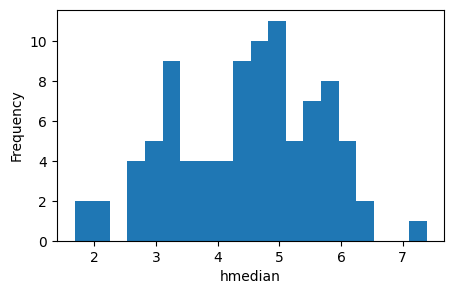

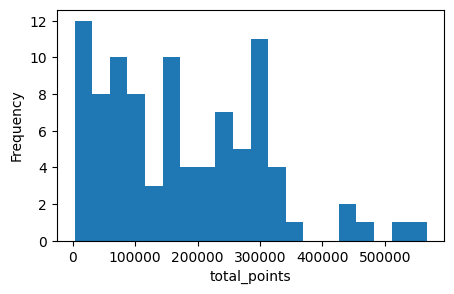

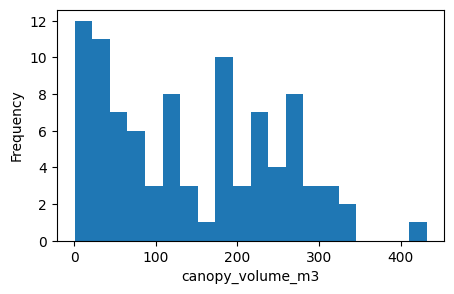

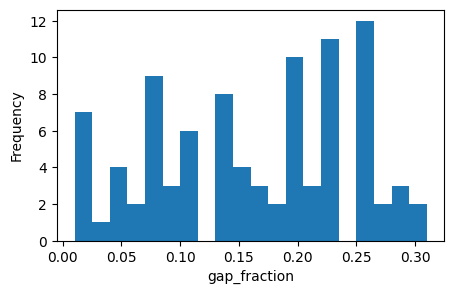

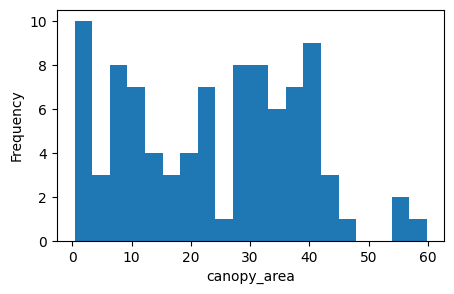

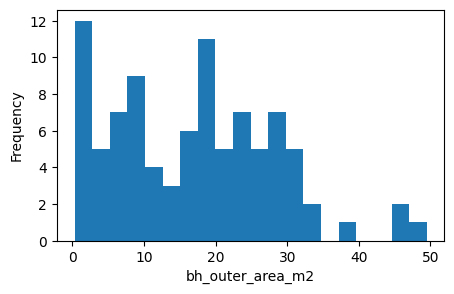

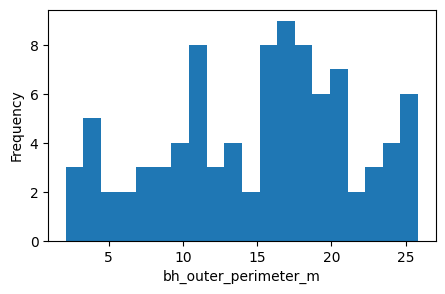

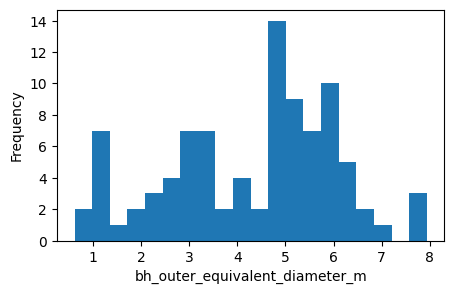

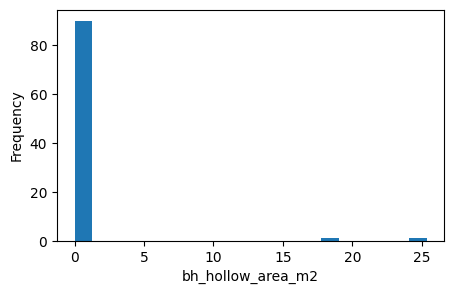

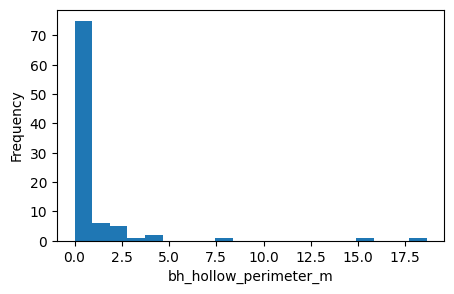

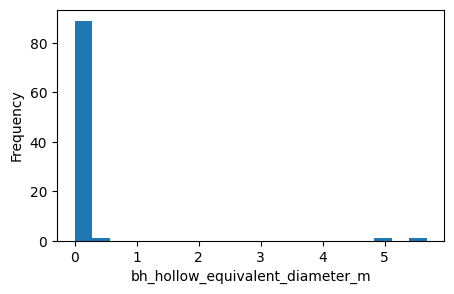

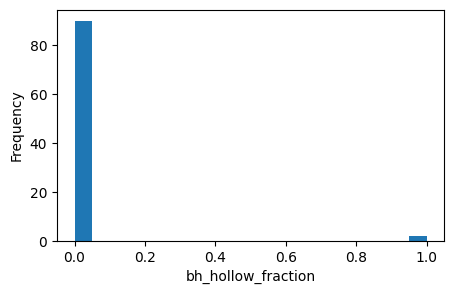

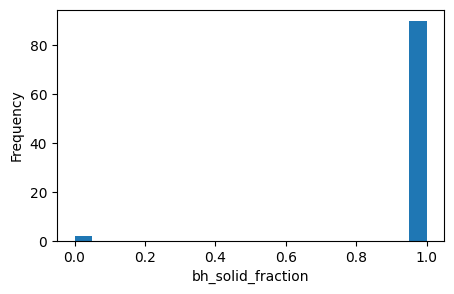

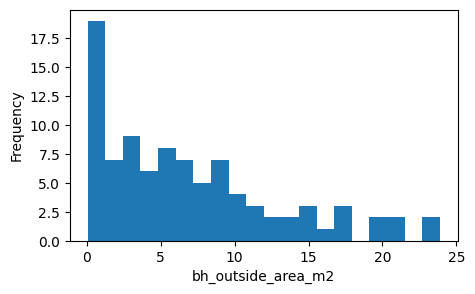

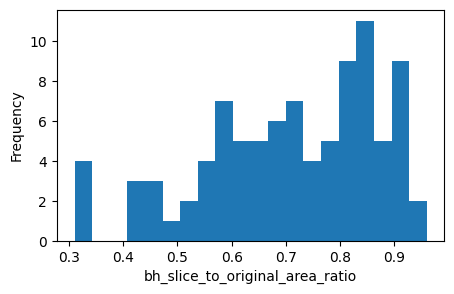

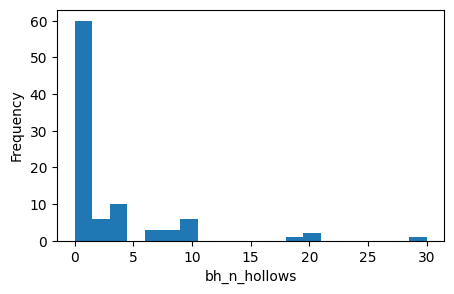

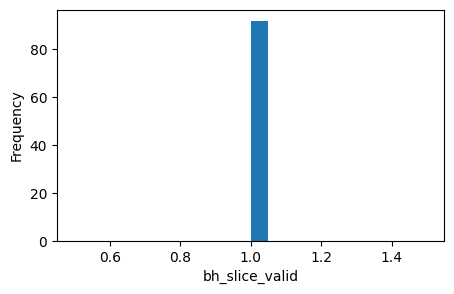

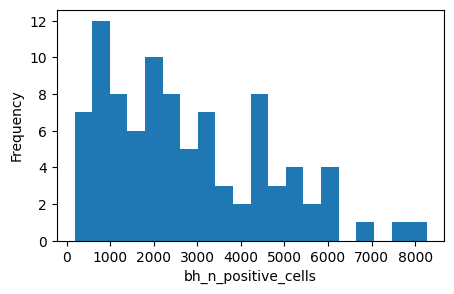

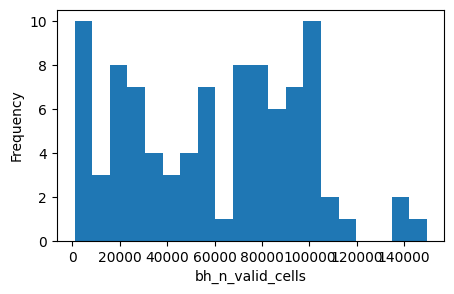

In [25]:
for predictor in predictors:
    plt.figure(figsize=(5,3))
    plt.hist(predictors_gdf[predictor], bins=20)
    plt.xlabel(f'{predictor}')
    plt.ylabel('Frequency')
    plt.show()

#### Is total biomass primarily driven by culm number or culm size?

In [26]:
df = gdf[gdf['total_agb'] != 0].copy()

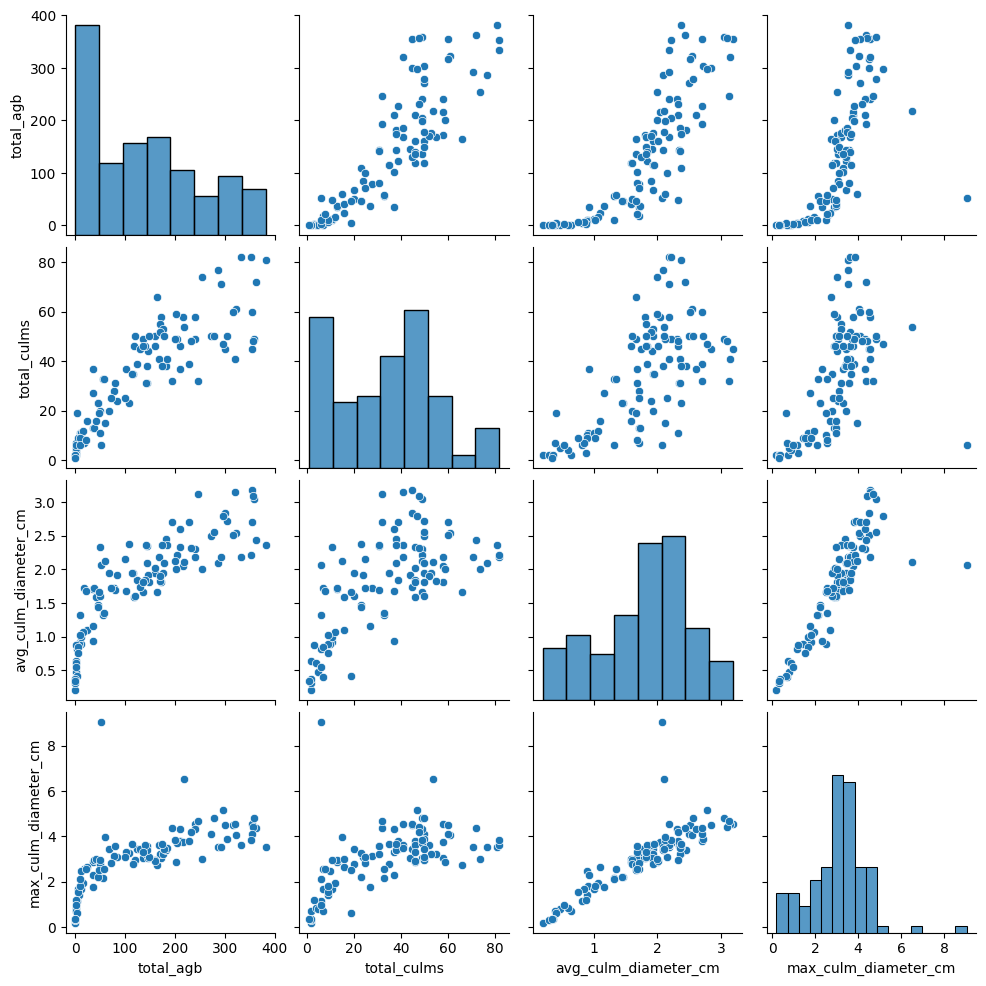

In [27]:
sns.pairplot(
    df[
        [
            "total_agb",
            "total_culms",
            "avg_culm_diameter_cm",
            "max_culm_diameter_cm"
        ]
    ]
)
plt.savefig(f'{inter_dir}/GRAPHICS/eda_pairplot_total_agb.png', dpi=300)
plt.show()

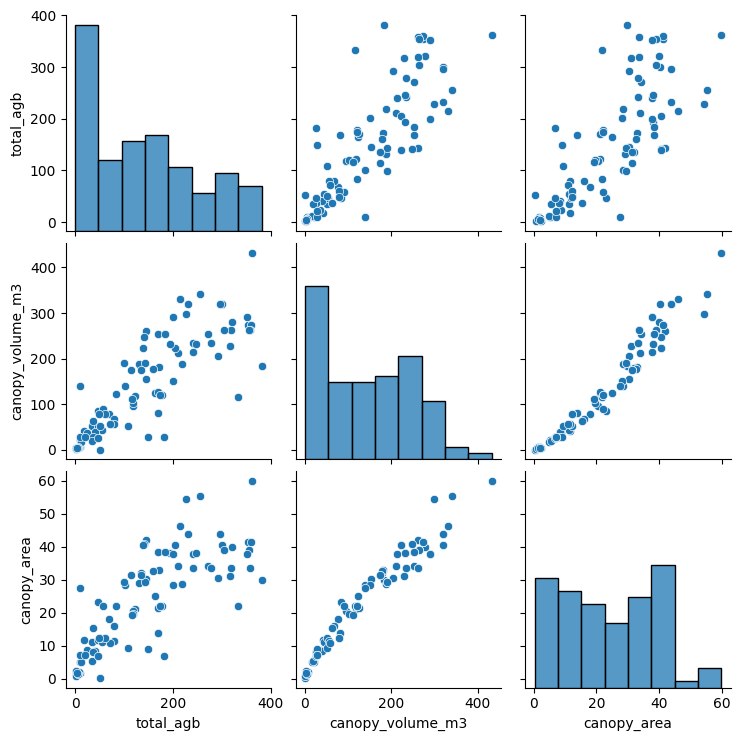

In [31]:
sns.pairplot(
    df[
        [
            "total_agb",
            "canopy_volume_m3",
            "canopy_area"
        ]
    ]
)
plt.savefig(f'{inter_dir}/GRAPHICS/eda_pairplot_volume.png', dpi=300)
plt.show()

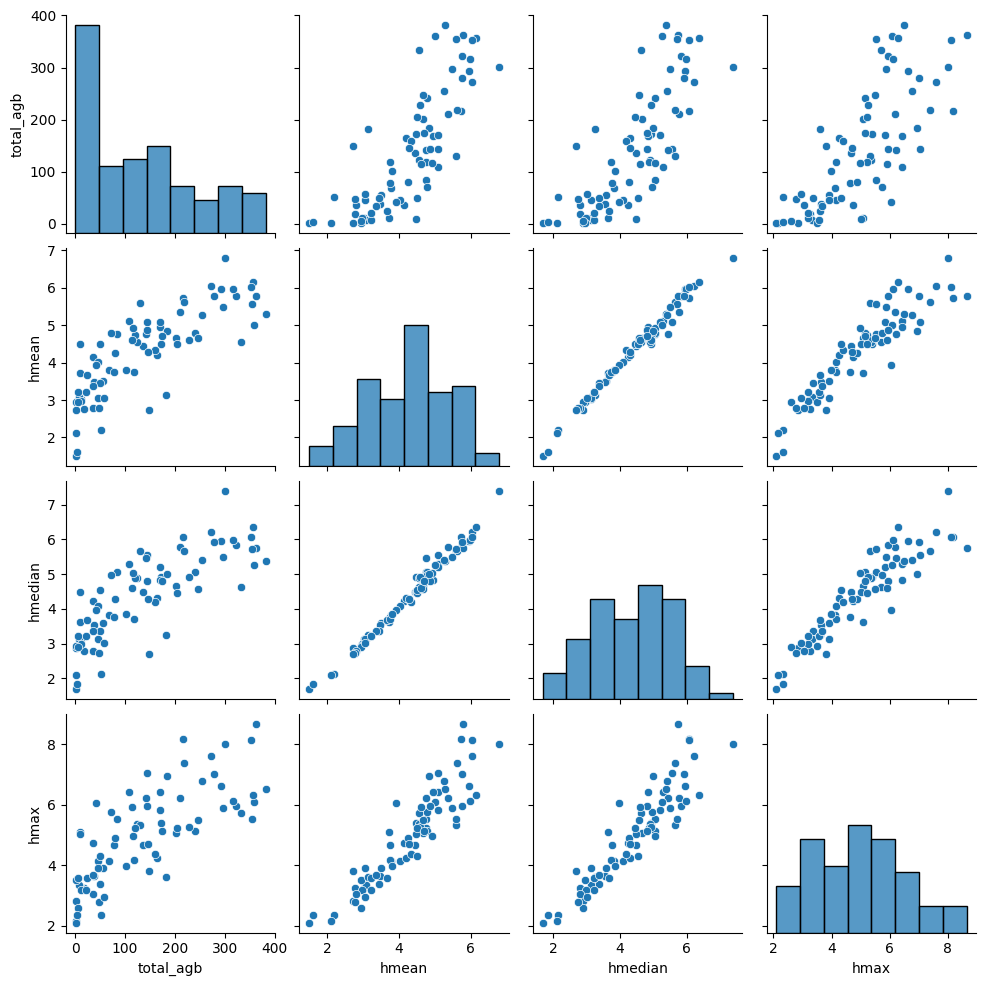

In [ ]:
sns.pairplot(
    df[
        [
            "total_agb",
            "hmean",
            "hmedian",
            "hmax"
        ]
    ]
)
plt.savefig(f'{inter_dir}/GRAPHICS/eda_pairplot_height.png', dpi=300)
plt.show()

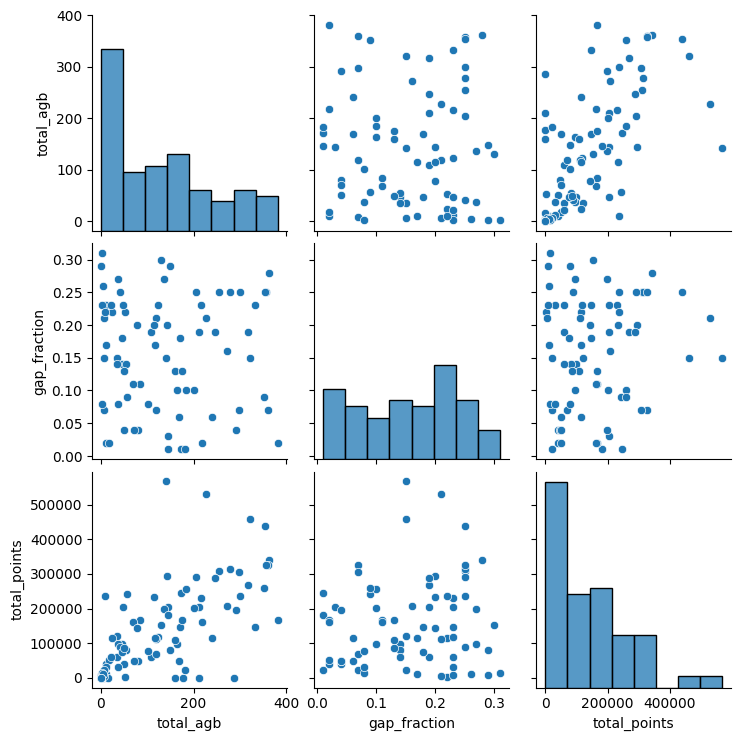

In [ ]:
sns.pairplot(
    df[
        [
            "total_agb",
            "gap_fraction",
            'total_points'
        ]
    ]
)
plt.savefig(f'{inter_dir}/GRAPHICS/eda_pairplot_density.png', dpi=300)
plt.show()

In [28]:
predictors_gdf.columns

Index(['psp', 'year', 'date_of_collection', 'clump_id', 'total_culms',
       'total_agb', 'max_culm_diameter_cm', 'avg_culm_diameter_cm',
       'min_culm_diameter_cm', 'median_culm_diameter_cm', 'max_culm_agb',
       'avg_culm_agb', 'min_culm_agb', 'median_culm_agb', 'hmin', 'hmax',
       'hmean', 'hstd', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'val_height', 'val_canopy_diameter',
       'bh_outer_area_m2', 'bh_outer_perimeter_m',
       'bh_outer_equivalent_diameter_m', 'bh_hollow_area_m2',
       'bh_hollow_perimeter_m', 'bh_hollow_equivalent_diameter_m',
       'bh_hollow_fraction', 'bh_solid_fraction', 'bh_outside_area_m2',
       'bh_slice_to_original_area_ratio', 'bh_n_hollows', 'bh_slice_valid',
       'bh_n_positive_cells', 'bh_n_valid_cells', 'geometry'],
      dtype='str')

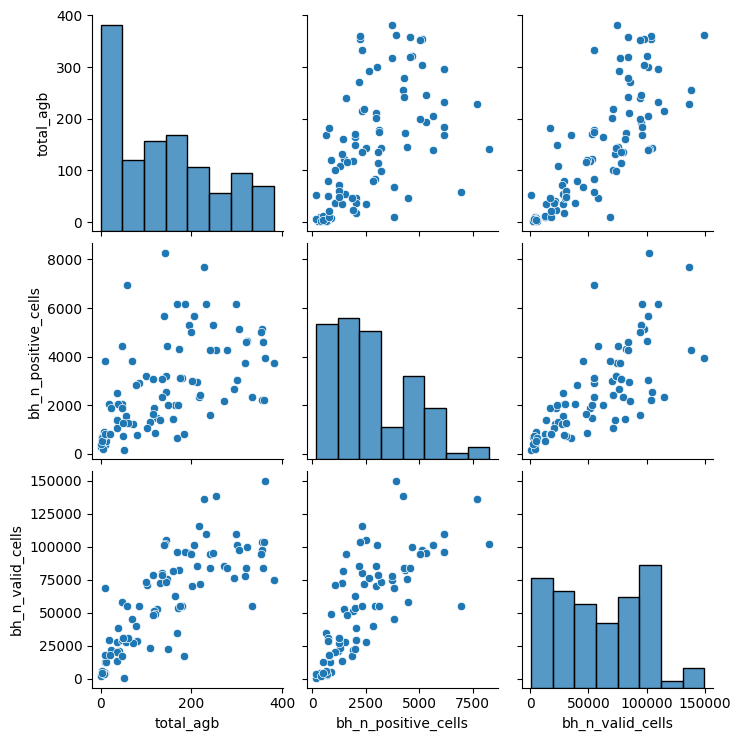

In [31]:
sns.pairplot(
    df[
        [
            "total_agb",
            'bh_n_positive_cells', 'bh_n_valid_cells'
        ]
    ]
)
# plt.savefig(f'{inter_dir}/GRAPHICS/eda_pairplot_density.png', dpi=300)
plt.show()

### Findings:
### 1. Above-Ground Biomass Dynamics

* **Non-Linear Scaling ("Banana" Curve):** 
  The relationship between all structural factors and `total_agb` is positive but distinctly non-linear. This geometric curvature is expected, as biomass scales volumetrically with diameter rather than linearly.
  
* **Culm Count Interactions ("Fan" Shape / Heteroscedasticity):** 
  The relationship between `total_culms` and `total_agb` approaches linearity but exhibits a strong fan-shaped spread (heteroscedasticity) toward the right. 
  * *Interpretation:* High biomass can be achieved by either having many medium size culms or few exceptionally thick culms


### 2. Culm Density and Diameter Relationships

* **Diminishing Returns (Total Culms vs. Max Culm Diameter):**
  There is a positive, non-linear relationship between the number of culms and the maximum culm diameter, which flattens out at higher densities.
  * *Interpretation:* This highlights a or ceiling effect. Beyond a certain culm density, severe resource competition (light, nutrients, water) prevents individuals from reaching larger maximum diameters, probably due to more shoots coming up and competing.

* **Independence of Average Size (Total Culms vs. Avg Culm Diameter):**
  The scatter plot between `total_culms` and `avg_culm_diameter_cm` displays a highly scattered, near-random distribution.
  * *Interpretation:* Number of culms does not appear to dictate the average diameter of the clump. Average thickness is likely governed by external variables such as clump age, genetic factors, or localized soil conditions rather than overcrowding.


In [61]:
df[
    [
        "total_agb",
        "total_culms",
        "avg_culm_diameter_cm",
        "max_culm_diameter_cm"
    ]
].corr(method="pearson")["total_agb"].sort_values(
    ascending=False
)

total_agb               1.000000
total_culms             0.869604
avg_culm_diameter_cm    0.839829
max_culm_diameter_cm    0.684260
Name: total_agb, dtype: float64

In [70]:
df[
    [
        "total_agb",
        "canopy_volume_m3",
        "canopy_area",
        "hmean",
        "hmedian",
        "hmax",
        "gap_fraction",
        'total_points',
        'adjusted_volume'
    ]
].corr(method="pearson")["total_agb"].sort_values(
    ascending=False)

total_agb           1.000000
canopy_volume_m3    0.837315
hmean               0.799749
hmedian             0.796505
canopy_area         0.790304
hmax                0.745804
total_points        0.682068
adjusted_volume     0.625753
gap_fraction       -0.034230
Name: total_agb, dtype: float64

In [54]:
df.columns

Index(['psp', 'year', 'date_of_collection', 'clump_id', 'total_culms',
       'total_agb', 'max_culm_diameter_cm', 'avg_culm_diameter_cm',
       'min_culm_diameter_cm', 'median_culm_diameter_cm', 'max_culm_agb',
       'avg_culm_agb', 'min_culm_agb', 'median_culm_agb', 'hmin', 'hmax',
       'hmean', 'hstd', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'val_height', 'val_canopy_diameter',
       'bh_slice_valid', 'bh_slice_area_m2', 'bh_slice_n_cells',
       'bh_slice_n_positive_cells', 'bh_slice_occupied_fraction',
       'bh_slice_mean_density', 'bh_slice_median_density',
       'bh_slice_std_density', 'bh_slice_density_cv', 'bh_slice_max_density',
       'bh_radial_density_integral', 'bh_radial_inner_density',
       'bh_radial_middle_density', 'bh_radial_outer_density',
       'bh_radial_inner_outer_ratio', 'bh_radial_weighted_mean',
       'bh_radial_weighted_sd', 'bh_radial_concentration',
       'bh_radial_n_valid_bins', 'bh_angular_dens

In [32]:
df[
    [
        "total_agb",
        'bh_outer_area_m2', 'bh_outer_perimeter_m',
       'bh_outer_equivalent_diameter_m', 'bh_hollow_area_m2',
       'bh_hollow_perimeter_m', 'bh_hollow_equivalent_diameter_m',
       'bh_hollow_fraction', 'bh_solid_fraction', 'bh_outside_area_m2',
       'bh_slice_to_original_area_ratio', 'bh_n_hollows', 'bh_slice_valid',
       'bh_n_positive_cells', 'bh_n_valid_cells'
    ]
].corr(method="pearson")["total_agb"].sort_values(
    ascending=False)

total_agb                          1.000000
bh_n_valid_cells                   0.790308
bh_outer_perimeter_m               0.744671
bh_outer_equivalent_diameter_m     0.728421
bh_outer_area_m2                   0.701467
bh_outside_area_m2                 0.627645
bh_n_positive_cells                0.540868
bh_hollow_perimeter_m              0.115556
bh_n_hollows                       0.114235
bh_hollow_area_m2                  0.104547
bh_hollow_equivalent_diameter_m    0.097916
bh_hollow_fraction                 0.064328
bh_slice_to_original_area_ratio   -0.010646
bh_solid_fraction                 -0.064328
bh_slice_valid                          NaN
Name: total_agb, dtype: float64

In [ ]:
selected_cols = [
    "canopy_volume_m3",
    "canopy_area",
    "hmean",
    "hmedian",
    "hmax",
    "gap_fraction",
    "total_points",
    'vertical_footprint_area_integral',
    'bh_slice_n_cells',
    'bh_slice_area_m2',
    'bh_slice_n_positive_cells',
    'vertical_occupied_fraction_integral',
    'bh_slice_occupied_fraction',
    "total_agb"
]

In [33]:
candidate_features = [
    'bh_outer_area_m2', 'bh_outer_perimeter_m',
           'bh_outer_equivalent_diameter_m', 'bh_hollow_area_m2',
           'bh_hollow_perimeter_m', 'bh_hollow_equivalent_diameter_m',
           'bh_hollow_fraction', 'bh_solid_fraction', 'bh_outside_area_m2',
           'bh_slice_to_original_area_ratio', 'bh_n_hollows', 'bh_slice_valid',
           'bh_n_positive_cells', 'bh_n_valid_cells'
]

In [34]:
from scipy.stats import pearsonr, spearmanr

results = []

for feature in candidate_features:

    x = df[feature]
    y = df["total_agb"]

    mask = x.notna() & y.notna()

    pearson_r, pearson_p = pearsonr(
        x[mask],
        y[mask]
    )

    spearman_r, spearman_p = spearmanr(
        x[mask],
        y[mask]
    )

    results.append({
        "feature": feature,
        "pearson_r": pearson_r,
        "spearman_r": spearman_r,
        "pearson_p": pearson_p,
        "spearman_p": spearman_p
    })

corr_df = pd.DataFrame(results)

corr_df.sort_values(
    "spearman_r",
    key=lambda x: abs(x),
    ascending=False
)

C:\Users\user\AppData\Local\Temp\ipykernel_14964\3567443007.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_r, pearson_p = pearsonr(
C:\Users\user\AppData\Local\Temp\ipykernel_14964\3567443007.py:17: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_r, spearman_p = spearmanr(


,feature,pearson_r,spearman_r,pearson_p,spearman_p
13,bh_n_valid_cells,0.790308,0.825457,7.515006e-21,4.488672e-24
1,bh_outer_perimeter_m,0.744671,0.788130,1.756035e-17,1.135640e-20
0,bh_outer_area_m2,0.701467,0.764022,6.832767e-15,8.111124e-19
2,bh_outer_equivalent_diameter_m,0.728421,0.763046,1.890953e-16,9.538326e-19
8,bh_outside_area_m2,0.627645,0.661200,2.148744e-11,7.308580e-13
12,bh_n_positive_cells,0.540868,0.650768,2.608561e-08,2.187671e-12
3,bh_hollow_area_m2,0.104547,0.226835,3.212990e-01,2.967477e-02
10,bh_n_hollows,0.114235,0.177165,2.782401e-01,9.113040e-02
5,bh_hollow_equivalent_diameter_m,0.097916,0.175887,3.531132e-01,9.352589e-02
4,bh_hollow_perimeter_m,0.115556,0.175870,2.726853e-01,9.355755e-02


In [35]:
corr_matrix = df[selected_cols].corr(method="pearson")

# 2. Plot the correlation matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,  # Displays correlation coefficients
    cmap="coolwarm",  # Diverging color palette (blue = negative, red = positive)
    fmt=".2f",  # Rounds to 2 decimal places
    vmin=-1,
    vmax=1,  # Standardizes the color bar limits
    square=True,  # Forces cells to be square-shaped
    linewidths=0.5,  # Adds lines between the cells for readability
)

plt.title("Correlation Matrix: Biomass & Canopy Metrics", fontsize=14, pad=20)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f'{inter_dir}/GRAPHICS/eda_corr_matrix.png', dpi=300)
plt.show()

NameError: name 'selected_cols' is not defined

C:\Users\user\AppData\Local\Temp\ipykernel_6132\3690868821.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agb_corr.values, y=agb_corr.index, palette="viridis")


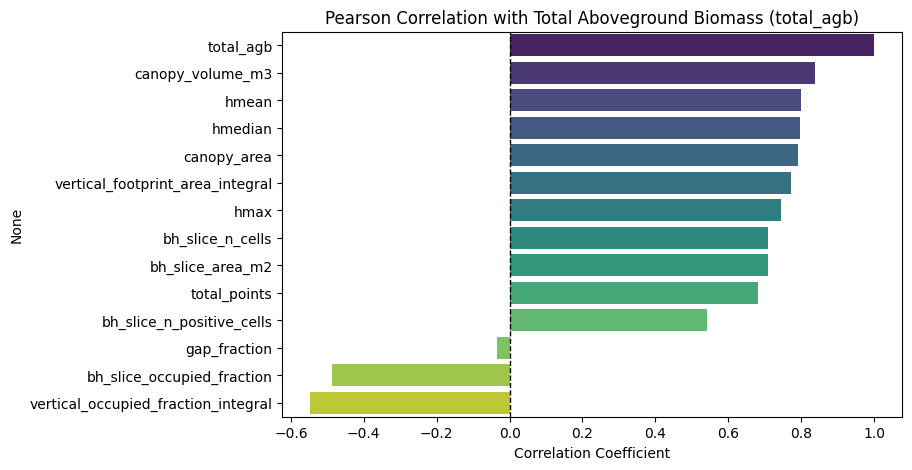

In [59]:
# Calculate correlation series against total_agb and sort
agb_corr = df[selected_cols].corr(method="pearson")["total_agb"].sort_values(ascending=False)

# Plot as a sorted bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=agb_corr.values, y=agb_corr.index, palette="viridis")
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Pearson Correlation with Total Aboveground Biomass (total_agb)")
plt.xlabel("Correlation Coefficient")
plt.show()


<!-- #### Does canopy volume actually contain more information than area + height? -->

In [ ]:
cols = [
    "canopy_area",
    "hmean",
    "hmax",
    "canopy_volume_m3"
]

df[cols].corr()

,canopy_area,hmean,hmax,canopy_volume_m3
canopy_area,1.000000,0.769699,0.754663,0.975526
hmean,0.769699,1.000000,0.920597,0.826882
hmax,0.754663,0.920597,1.000000,0.818353
canopy_volume_m3,0.975526,0.826882,0.818353,1.000000


In [ ]:
df[
    [
        "canopy_volume_m3",
        "canopy_area",
        "hmean"
    ]
].corr()

,canopy_volume_m3,canopy_area,hmean
canopy_volume_m3,1.000000,0.975526,0.826882
canopy_area,0.975526,1.000000,0.769699
hmean,0.826882,0.769699,1.000000


<!-- #### Key Finding:
* **High Multicollinearity:** `canopy_volume_m3` is almost perfectly correlated with `canopy_area` ($r = 0.974$) and highly correlated with mean height (`hmean`, $r = 0.833$). 
* **Information Redundancy:** Volume is mathematically a function of area and height. The extremely high correlation coefficients prove that calculating volume does not introduce significant "new" structural information or variance to the dataset.
* **Modeling Implication:** If we include all three variables in a linear regression model to predict `total_agb`, it will cause severe **multicollinearity**. This will inflate standard errors and make individual variable importances unreliable. We should drop `canopy_volume_m3` and stick to the two independent structural metrics (`canopy_area` and `hmean`), or use volume *instead* of them, but never both. -->

<!-- #### Does point density tell us anything? -->

In [ ]:
df["point_density"] = (
    df["total_points"] /
    df["canopy_area"]
)

In [ ]:
df[
    [
        "total_agb",
        "total_points",
        "point_density"
    ]
].corr()

,total_agb,total_points,point_density
total_agb,1.000000,0.659379,-0.122028
total_points,0.659379,1.000000,0.295696
point_density,-0.122028,0.295696,1.000000


<!-- #### Key Findings:
* **Point Density is Irrelevant for Biomass:** The correlation between `point_density` and `total_agb` is near-zero. Point density often reflects sensor settings, flight altitudes, or trivial canopy surface clutter (leaves/twigs) rather than actual wood volume or mass. It provides no predictive power for biomass.
* **Total Points Capture Size:** `total_points` has a solid positive relationship with biomass ($r = 0.68$). This is because `total_points` acts as a proxy for the overall volumetric footprint (size) of the clump.
* **Size Beats Structure:** Canopy size dimensions (Area, Height, and Total Points) are far better predictors of biomass than internal canopy density. When building predictive models, `point_density` can safely be excluded. -->

<!-- #### Does gap fraction contain useful information? -->

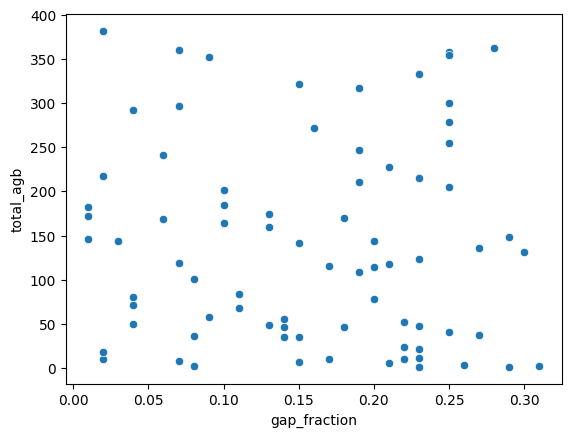

In [ ]:
sns.scatterplot(
    data=df,
    x="gap_fraction",
    y="total_agb"
)

plt.show()

<!-- #### Conclusion:
* **Gap Fraction is Uninformative:** The percentage of gaps or openings in the canopy layer has no statistical relationship with above-ground biomass. A canopy can be highly fractured or tightly closed without it reflecting the actual weight of the structural biomass below.
* **The "Size vs. Structure" Case is Closed:** This finding perfectly aligns with our previous analysis of `point_density`. Both metrics try to quantify internal canopy structure, and both completely fail to correlate with biomass.
* **Final Modeling Strategy:** Above-ground biomass (`total_agb`) in this ecosystem is overwhelmingly driven by **canopy size** (`canopy_area`, `hmean`) and direct structural dimensions (`total_culms`, culm diameters). Internal canopy characteristics should be permanently excluded from the feature selection pool as they add noise rather than signal. -->

<!-- #### Does site affect biomass relationships? -->

In [ ]:
df.groupby("psp")["total_agb"].describe()

,count,mean,std,min,25%,50%,75%,max
psp,,,,,,,,
1a-APM-01,15.0,58.412000,66.943427,0.10,10.4800,35.490,76.0900,211.12
1a-APM-02,15.0,71.606667,64.651775,1.31,14.0250,51.940,120.5400,215.70
1a-APM-07,14.0,127.758571,84.318575,5.94,57.4875,139.670,174.6275,286.94
1a-APM-08,15.0,127.837333,124.868854,0.21,5.1000,115.930,209.6100,382.05
1a-APM-13,5.0,75.784000,87.745381,0.30,46.0700,47.430,57.4300,227.69
1a-GB-03,12.0,213.554167,123.408311,0.13,147.1200,233.075,318.2075,362.77
1a-GB-05,14.0,224.202143,115.496522,21.01,151.0325,225.700,338.4375,359.82


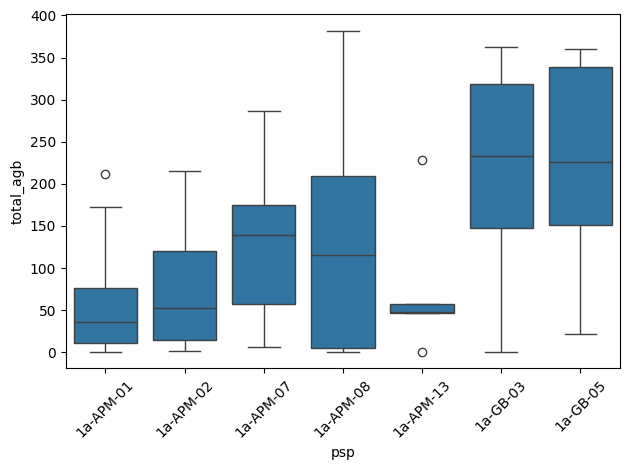

In [ ]:
sns.boxplot(
    data=df,
    x="psp",
    y="total_agb"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{inter_dir}/GRAPHICS/eda_biomass_site_effect.png', dpi=300)
plt.show()

<!-- #### Key Findings & Interpretation:
* **Strong Site Effect (GB vs. APM):** There is a distinct difference between sites. The `1a-GB` sites are highly productive, yielding mean biomass values ($>200$) that are 2x to 3x higher than early `1a-APM` sites (which hover around 58–71). 
* **High Internal Variance:** The standard deviations (`std`) are remarkably high at every single site. This shows that while a site dictates the *average environmental capacity* (e.g., better soil or moisture at GB sites), individual clump structural traits still drive huge internal diversity. -->

<!-- #### More importantly: does the drone-biomass relationship change by PSP? -->

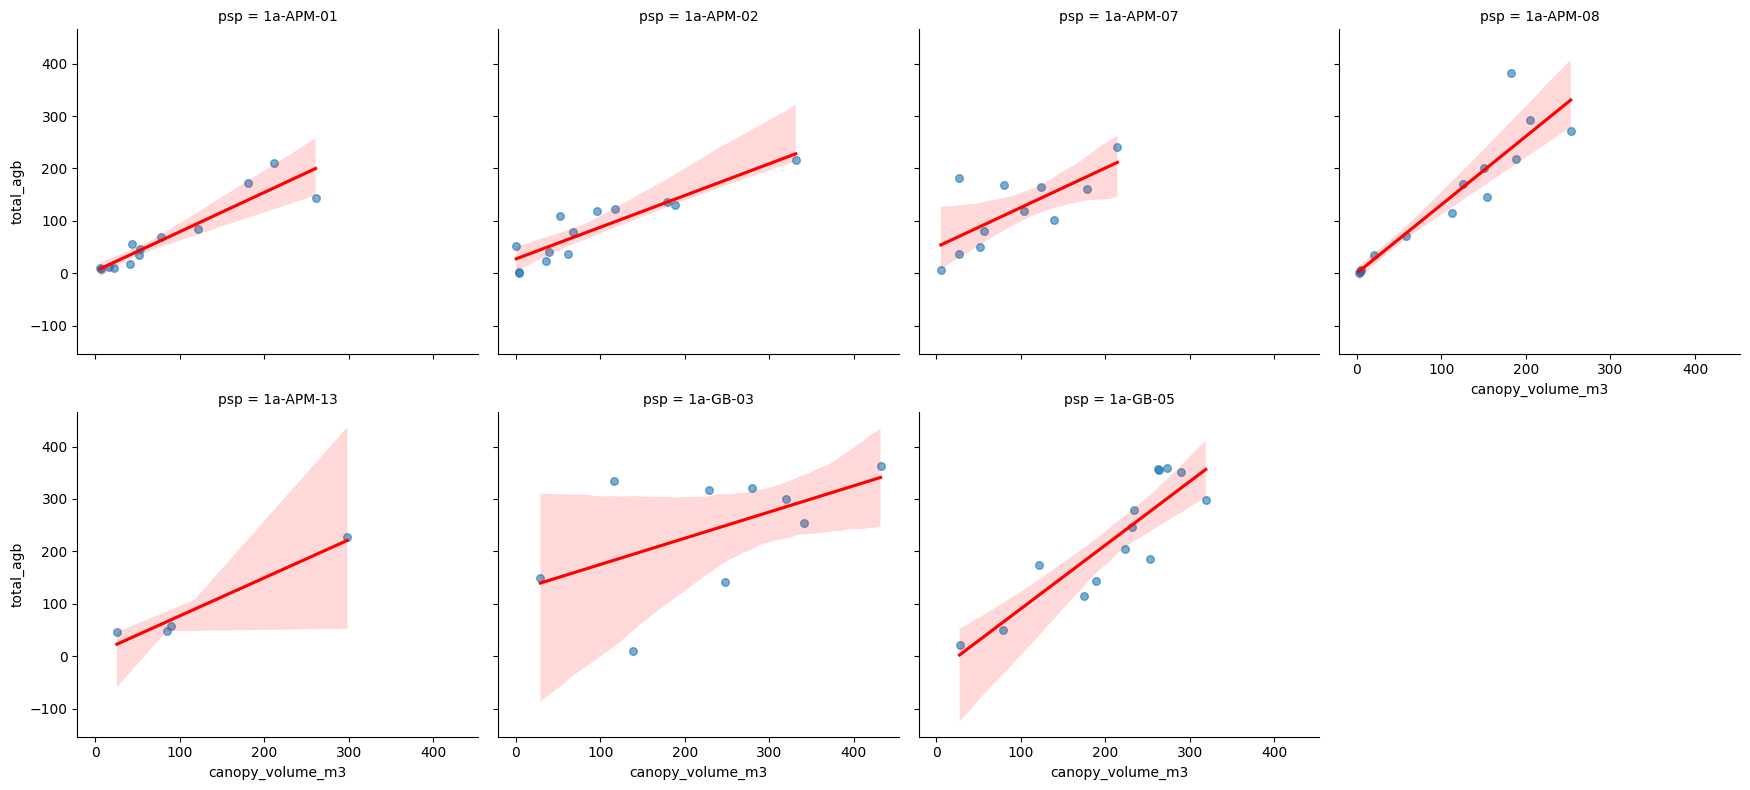

In [ ]:
g = sns.lmplot(
    data=df,
    x="canopy_volume_m3",  
    y="total_agb",
    col="psp",        # Creates a separate subplot for each site
    col_wrap=4,       # Wraps the subplots into a clean 3-column grid
    height=4,
    aspect=1.1,
    scatter_kws={"alpha": 0.6, "s": 30},  # Makes dots slightly transparent and smaller
    line_kws={"color": "red"}             # Keeps regression lines bold and easy to read
)

# Adjust spacing so titles don't overlap
plt.tight_layout()
plt.savefig(f'{inter_dir}/GRAPHICS/eda_canopy_volume_agb_per_psp.png', dpi = 300)
plt.show()

In [ ]:
# Define the non-redundant, high-value factors you identified
factors = ['total_agb', 'total_culms', 'canopy_area', 'hmean', 'canopy_volume_m3', 'avg_culm_diameter_cm']

# Create an empty list to store our structured site correlation data
site_corrs = []

# Loop through each unique plot and grab its specific correlation values
for psp, group in df.groupby('psp'):
    # Run correlation only if there are enough points to calculate a meaningful relationship
    if len(group) > 3:
        corr_matrix = group[factors].corr()
        
        # Pull out the specific correlations of interest relative to Above-Ground Biomass
        site_corrs.append({
            'PSP Site': psp,
            'Sample Size (N)': len(group),
            'AGB vs. Culms': corr_matrix.loc['total_agb', 'total_culms'],
            'AGB vs. Canopy Area': corr_matrix.loc['total_agb', 'canopy_area'],
            'AGB vs. Height (hmean)': corr_matrix.loc['total_agb', 'hmean'],
            'Culms vs. Area': corr_matrix.loc['total_culms', 'canopy_area'],
            'AGB vs. Canopy Volume': corr_matrix.loc['total_agb', 'canopy_volume_m3'],
            'AGB vs. Culm Diameter': corr_matrix.loc['total_agb', 'avg_culm_diameter_cm']
        })

# Combine into a clean summary DataFrame
df_site_summary = pd.DataFrame(site_corrs).round(3)

# Display the summary table sorted by the strength of the Canopy Area relationship
display(df_site_summary.sort_values(by='AGB vs. Canopy Area', ascending=False))


,PSP Site,Sample Size (N),AGB vs. Culms,AGB vs. Canopy Area,AGB vs. Height (hmean),Culms vs. Area,AGB vs. Canopy Volume,AGB vs. Culm Diameter
4,1a-APM-13,5,0.789,0.938,0.989,0.752,0.977,0.915
0,1a-APM-01,15,0.916,0.928,0.861,0.785,0.930,0.798
3,1a-APM-08,15,0.945,0.911,0.840,0.879,0.923,0.902
1,1a-APM-02,15,0.948,0.908,0.818,0.940,0.911,0.736
6,1a-GB-05,14,0.840,0.792,0.840,0.757,0.880,0.741
2,1a-APM-07,14,0.919,0.667,0.657,0.711,0.704,0.858
5,1a-GB-03,12,0.894,0.404,0.586,0.260,0.530,0.828


<!-- #### Core Inferences:

* **Canopy Saturation in High-Biomass Sites (`1a-GB-03`):**
  We observe a major structural breakdown in the `1a-GB-03` plot. The correlation between `total_agb` and `canopy_area` drops drastically to **0.404** (compared to $>0.90$ in early APM sites). 
  * *Ecological Inference:* In highly productive or mature sites, the canopy layer reaches a closed state (saturation). Once the canopy completely covers the plot area, the pace of canopy area and biomass increase starts to slow. Canopy area starts increasing slowly as the clump builds mass underneath.

* **Ground Metrics Stand Firm:**
  Even where canopy metrics fail to predict biomass (`1a-GB-03`), ground-truth metrics like `total_culms` ($r = 0.894$) and `avg_culm_diameter` ($r = 0.828$) remain exceptionally strong and stable predictors across *all* sites.
  * *Ecological Inference:* Ground-level density and stalk dimensions are universally reliable. Remote sensing canopy metrics are highly accurate for young/sparse plots (`APM-01`, `APM-02`, `APM-08`), but degrade in high-density, high-biomass environments.

* **Modeling Action Plan:**
  Because the predictive power of canopy size changes so drastically based on the location, a single global linear regression model will struggle. We have two clear paths forward:
  1. **Tree-Based Models:** Use an algorithm like Random Forest or Gradient Boosting, passing `psp` as an encoded feature so the model can learn these conditional rules natively.
  2. **Stratified Modeling:** Build separate predictive equations for `APM` sites (canopy-driven) vs. `GB` sites. -->


<!-- #### Are the largest clumps fundamentally different? -->

In [ ]:
df["biomass_group"] = pd.qcut(
    df["total_agb"],
    q=4,
    labels=[
        "Low",
        "Medium-Low",
        "Medium-High",
        "High"
    ]
)

In [ ]:
df.groupby("biomass_group")[
    [
        "total_agb",
        "canopy_area",
        "canopy_volume_m3",
        "hmean",
        "total_culms",
        "avg_culm_diameter_cm"
    ]
].median()

,total_agb,canopy_area,canopy_volume_m3,hmean,total_culms,avg_culm_diameter_cm
biomass_group,,,,,,
Low,4.32,2.060,5.50,2.97,7.0,0.82
Medium-Low,53.57,12.130,56.76,3.80,23.5,1.70
Medium-High,160.05,28.645,152.14,4.61,47.5,1.93
High,292.78,37.900,262.07,5.61,58.0,2.50


<!-- #### Inferences:

* **Allometric Scaling Strategy:**
  High-biomass clumps are fundamentally different because they execute a multi-dimensional growth strategy. To reach the "High" tier, clumps simultaneously maximize ground metrics (count and diameter) and canopy metrics (area and height). 
  
* **Vertical Saturation vs. Horizontal Expansion:**
  Between the top two tiers (Medium-High to High), height growth slows down drastically ($+1.0\text{m}$), whereas canopy area continues to widen aggressively ($+9.25\text{m}^2$). This indicates that biomass accumulation in mature clumps shifts from vertical competition for light to horizontal territory expansion.

* **Ground-Level:**
  The most dramatic transformation occurs at ground level. High-biomass clumps support $8\times$ more culms than low-biomass ones, and those culms are $3\times$ thicker on average. Because weight scales with the square of the diameter ($\text{Area} \propto d^2$), the concurrent increase in both culm thickness and culm count explains the geometric explosion in `total_agb`. -->

<!-- #### Is biomass density more predictable than total biomass? -->

In [ ]:
df["agb_per_area"] = (
    df["total_agb"] /
    df["canopy_area"]
)

df["agb_per_volume"] = (
    df["total_agb"] /
    df["canopy_volume_m3"]
)

In [ ]:
df.columns

Index(['psp', 'year', 'date_of_collection', 'clump_id', 'total_culms',
       'total_agb', 'max_culm_diameter_cm', 'avg_culm_diameter_cm',
       'min_culm_diameter_cm', 'median_culm_diameter_cm', 'max_culm_agb',
       'avg_culm_agb', 'min_culm_agb', 'median_culm_agb', 'hmin', 'hmax',
       'hmean', 'hstd', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'val_height', 'val_canopy_diameter',
       'geometry', 'adjusted_volume', 'point_density', 'biomass_group',
       'agb_per_area', 'agb_per_volume'],
      dtype='str')

In [ ]:
targets = ["avg_culm_diameter_cm", "total_culms"]
features = ['canopy_area', 'canopy_volume_m3', 'hmean']

for target in targets:
    # 1. Include the target in the slice
    sliced_df = df[features + [target]]
    
    # 2. Compute correlation and extract just the target's column
    correlation_series = sliced_df.corr()[target]
    
    # 3. Print the features relative to that target (excluding the target correlating with itself)
    print(f"\nCorrelation for {target}:")
    print(correlation_series[features])


Correlation for avg_culm_diameter_cm:
canopy_area         0.579215
canopy_volume_m3    0.630654
hmean               0.570646
Name: avg_culm_diameter_cm, dtype: float64

Correlation for total_culms:
canopy_area         0.757025
canopy_volume_m3    0.817611
hmean               0.802620
Name: total_culms, dtype: float64


<!-- #### Core Inferences:
* **The Cancellation Trap:**  Since absolute size is the primary driver of total mass, density metrics erase the most valuable predictive signals in the dataset.
* **Density Flattening:** Biomass density can be identical for an extremely small clump and a massive, mature clump. Because remote sensing features measure the *outer structural boundary*, they cannot differentiate density variations independent of scale.
* **Final Modeling Strategy:** The absolute metric `total_agb` must remain the target variable for all predictive pipelines. The canopy size metrics retain strong linear and non-linear relationships with total mass that will be highly effective in a machine learning framework. -->

<!-- ### PART TWO -->

In [ ]:
df.columns

Index(['psp', 'year', 'date_of_collection', 'clump_id', 'total_culms',
       'total_agb', 'max_culm_diameter_cm', 'avg_culm_diameter_cm',
       'min_culm_diameter_cm', 'median_culm_diameter_cm', 'max_culm_agb',
       'avg_culm_agb', 'min_culm_agb', 'median_culm_agb', 'val_height',
       'val_canopy_diameter', 'hmin', 'hmax', 'hmean', 'hstd', 'hmedian',
       'total_points', 'canopy_volume_m3', 'gap_fraction', 'canopy_area',
       'bh_openness_integral', 'bh_interior_edge_ratio', 'bh_inflection_u',
       'bh_inflection_curvature', 'bh_arc_length', 'bh_beer_lambert_A',
       'bh_beer_lambert_k', 'bh_n_cells', 'vertical_density_integral',
       'vertical_k_integral', 'n_valid_height_slices', 'drone_match_status',
       'geometry'],
      dtype='str')

In [ ]:
df.head()

,psp,year,date_of_collection,clump_id,total_culms,total_agb,max_culm_diameter_cm,avg_culm_diameter_cm,min_culm_diameter_cm,median_culm_diameter_cm,...,bh_arc_length,bh_beer_lambert_A,bh_beer_lambert_k,bh_n_cells,vertical_density_integral,vertical_k_integral,n_valid_height_slices,drone_match_status,geometry,adjusted_volume
3,1a-GB-05,2026,6/24/2026,CLUMP #2,49,359.82,4.82,3.05,1.42,3.03,...,4.78,2.96,-5.47,103464.0,207.14,-3.24,6.0,Matched,POINT (799042.944 9763205.838),19.1485
5,1a-GB-05,2026,6/24/2026,CLUMP #3,38,143.28,3.42,2.09,0.81,1.94,...,6.02,90.59,-1.03,73335.0,267.79,-1.61,6.0,Matched,POINT (799048.509 9763203.175),37.8720
7,1a-GB-05,2026,6/24/2026,CLUMP #4,50,278.97,4.82,2.56,1.02,2.38,...,NaN,84.82,-1.46,83612.0,254.37,-2.32,6.0,Matched,POINT (799057.336 9763202.666),58.3300
9,1a-GB-05,2026,6/24/2026,CLUMP #5,48,357.45,4.41,3.09,0.95,3.18,...,6.89,184.96,0.10,84175.0,285.92,0.93,6.0,Matched,POINT (799063.617 9763203.957),65.5175
11,1a-GB-05,2026,6/24/2026,CLUMP #6,60,354.98,4.10,2.71,0.71,2.73,...,9.94,45.72,-2.58,97706.0,312.24,-3.20,6.0,Matched,POINT (799067.17 9763205.937),65.8850


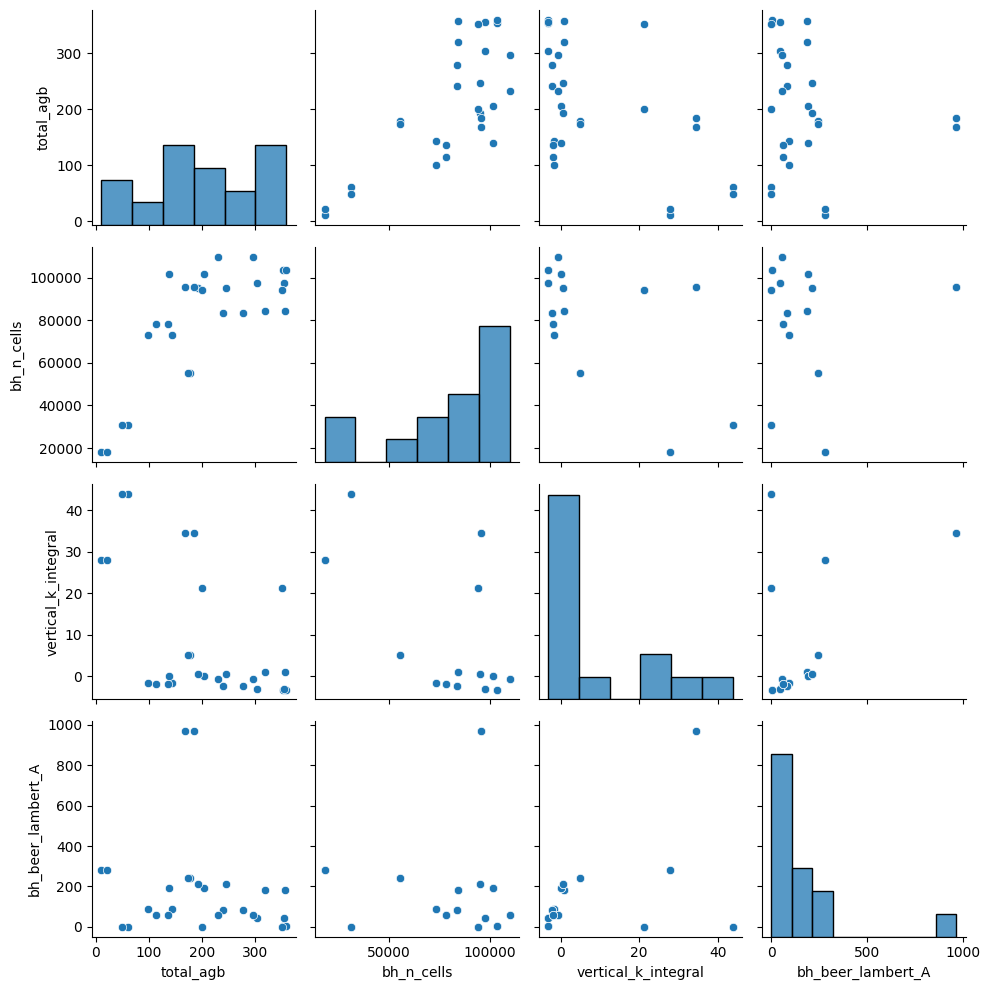

In [ ]:
sns.pairplot(
    df[
        [
            "total_agb",
            "bh_n_cells",
            "vertical_k_integral",
            "bh_beer_lambert_A"
        ]
    ]
)
# plt.savefig(f'{inter_dir}/GRAPHICS/eda_pairplot_height.png', dpi=300)
plt.tight_layout()
plt.show()